# 1 Installing the YOLOv8 Environment

To start off with YOLOv8 we first clone the YOLOv8 repository and install dependencies. This will set up our programming environment to be ready to running object detection training and inference commands.

In [1]:
# Clone repository
!git clone https://github.com/ultralytics/ultralytics

# Navigate to the cloned directory
%cd ultralytics

# Install the package in editable mode for development
!pip install -e .

C:\Users\CP1\Documents\GitHub\Itemized-Billing\ultralytics


fatal: destination path 'ultralytics' already exists and is not an empty directory.


Obtaining file:///C:/Users/CP1/Documents/GitHub/Itemized-Billing/ultralytics
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.171
    Uninstalling ultralytics-8.0.171:
      Successfully uninstalled ultralytics-8.0.171
  Running setup.py develop for ultralytics


# 2 Import Libraries

In [2]:
import torch
print('torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))
from ultralytics import YOLO

import yaml
import glob
from IPython.display import Image, display
from IPython.core.magic import register_line_cell_magic

from DataAugmentation import DataAugmentation

torch 1.13.1+cu116 _CudaDeviceProperties(name='NVIDIA GeForce RTX 3090', major=8, minor=6, total_memory=24575MB, multi_processor_count=82)


In [3]:
%cd ..

# Open and read the YAML file
with open('config-TCD.yaml', 'r') as file:
    yaml_data = yaml.safe_load(file)

yaml_data

C:\Users\CP1\Documents\GitHub\Itemized-Billing


{'path': 'C:/Users/CP1/Documents/GitHub/Itemized-Billing/TCD-yolo-1.1',
 'train': 'train.txt',
 'val': 'valid.txt',
 'nc': 1,
 'names': ['row']}

In [4]:
# Define number of classes based on YAML
with open('config-TCD.yaml', 'r') as stream:
    num_classes = str(yaml.safe_load(stream)['nc'])

print(f'Number of class: {num_classes}')

Number of class: 1


In [5]:
import os

current_directory = os.getcwd()
print("Current Directory:", current_directory)

Current Directory: C:\Users\CP1\Documents\GitHub\Itemized-Billing


# 3 Train YOLOv8

In [14]:
model = YOLO('yolov8s.pt')  # build a new model from scratch

results = model.train(data='config-TCD.yaml', epochs=1000, workers=1, imgsz=416)  # train the model

New https://pypi.org/project/ultralytics/8.0.186 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.171  Python-3.10.10 torch-1.13.1+cu116 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
WARNING  Upgrade to torch>=2.0.0 for deterministic training.
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=config-TCD.yaml, epochs=1000, patience=50, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=1, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream

# 4 Evaluate the model

In [8]:
results.results_dict

{'metrics/precision(B)': 0.3564977270772257,
 'metrics/recall(B)': 0.5511221945137157,
 'metrics/mAP50(B)': 0.4075626463563056,
 'metrics/mAP50-95(B)': 0.15068161633415458,
 'fitness': 0.1763697193363697}

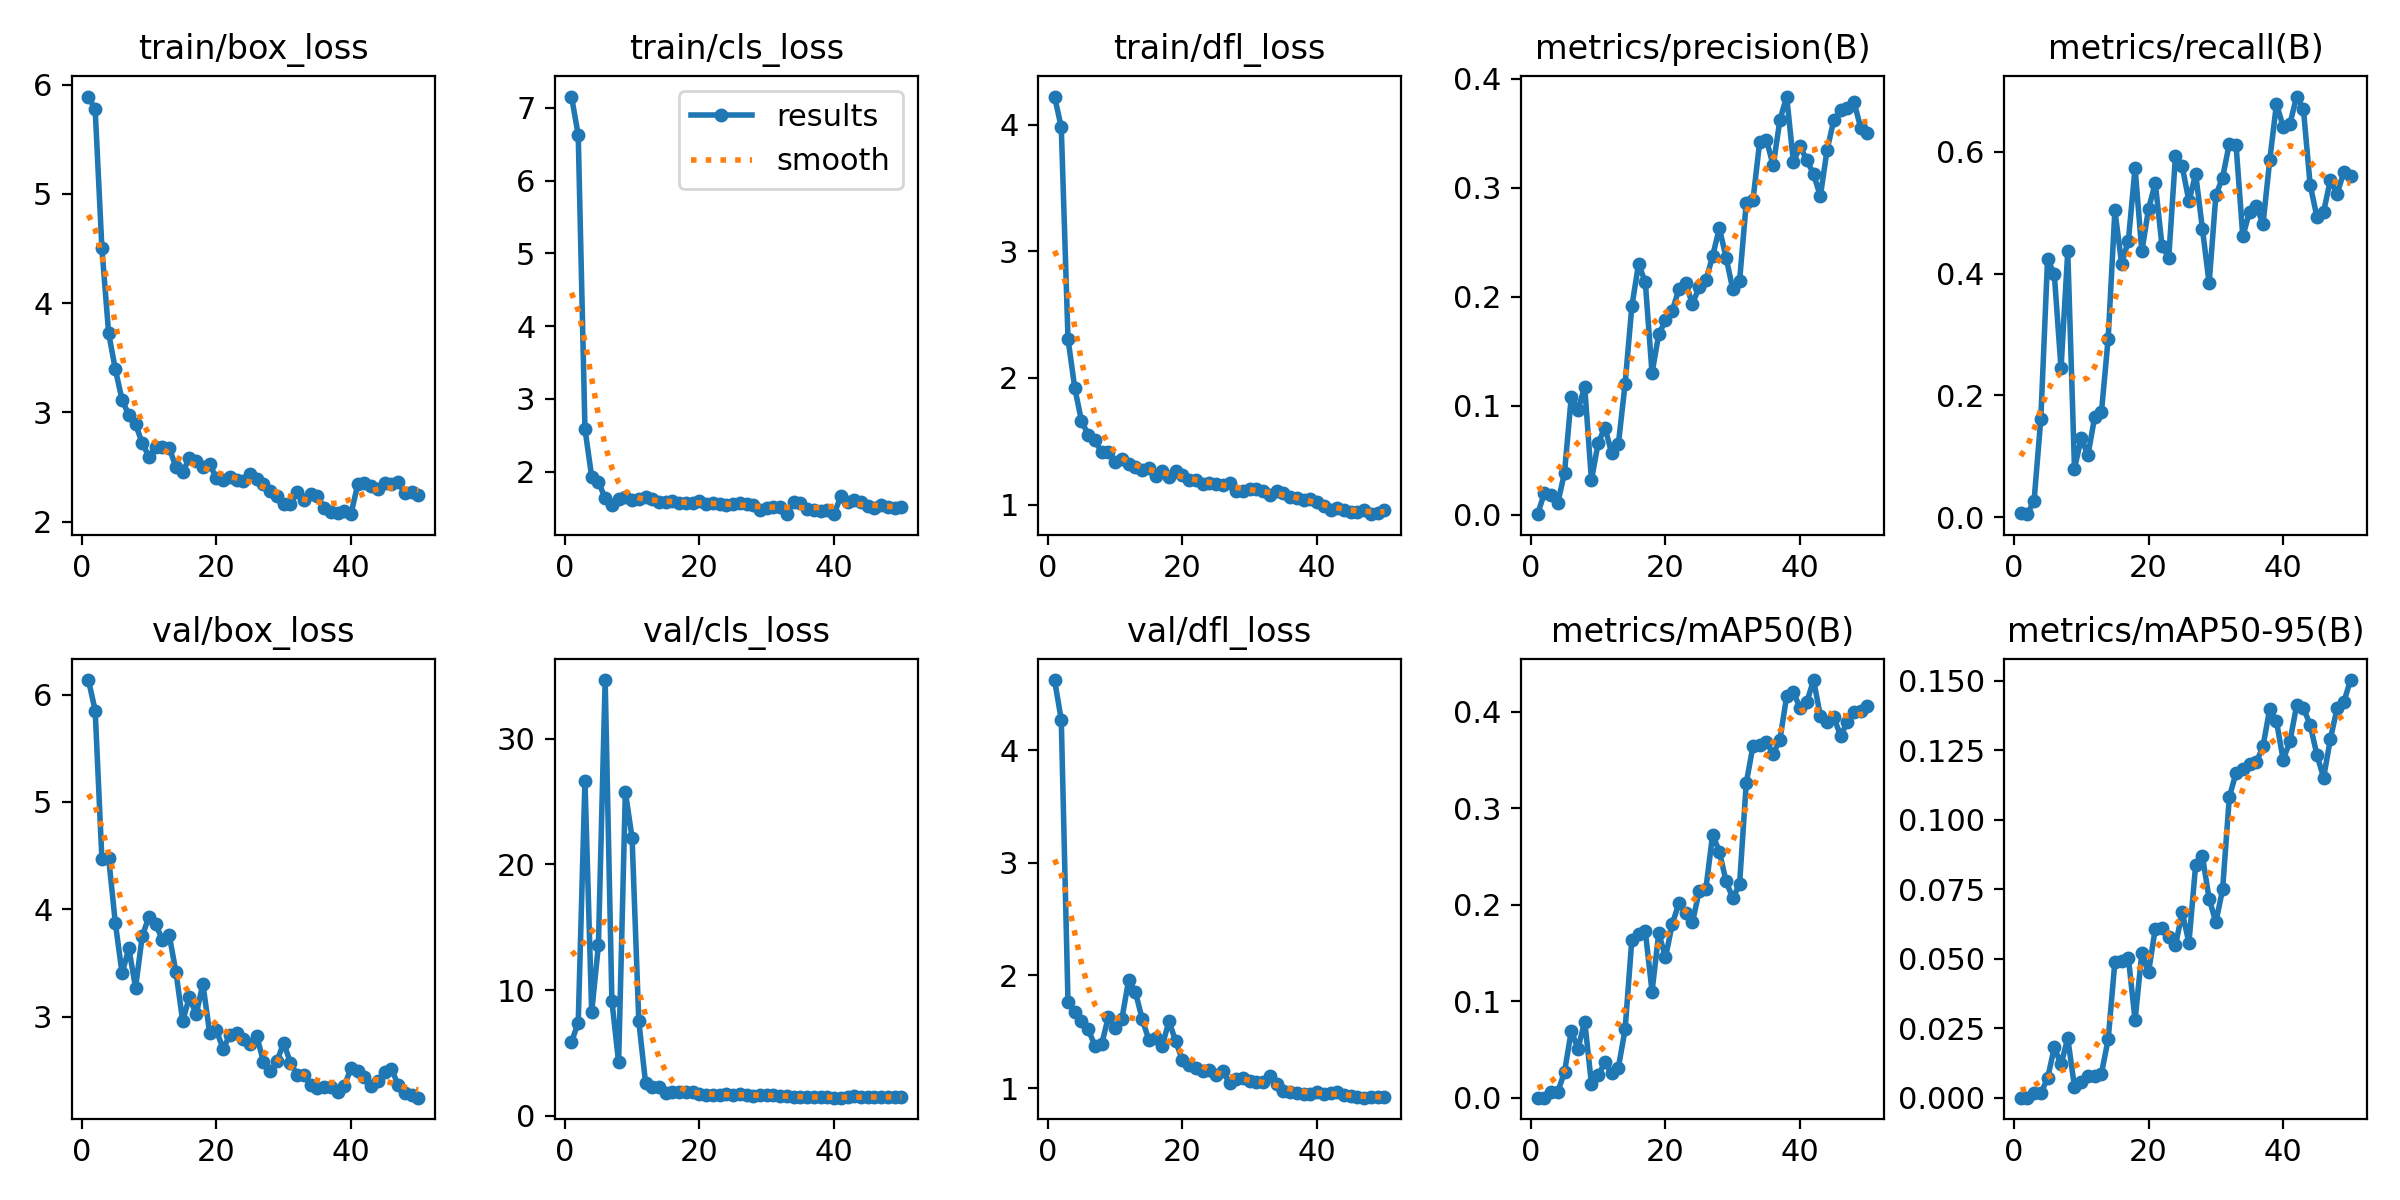

In [9]:
# We can also output some older school graphs if the tensor board isn't working for whatever reason...
Image(filename=f'{str(results.save_dir)}/results.png', width=1000)

## 4.1 Visualize the Training Data

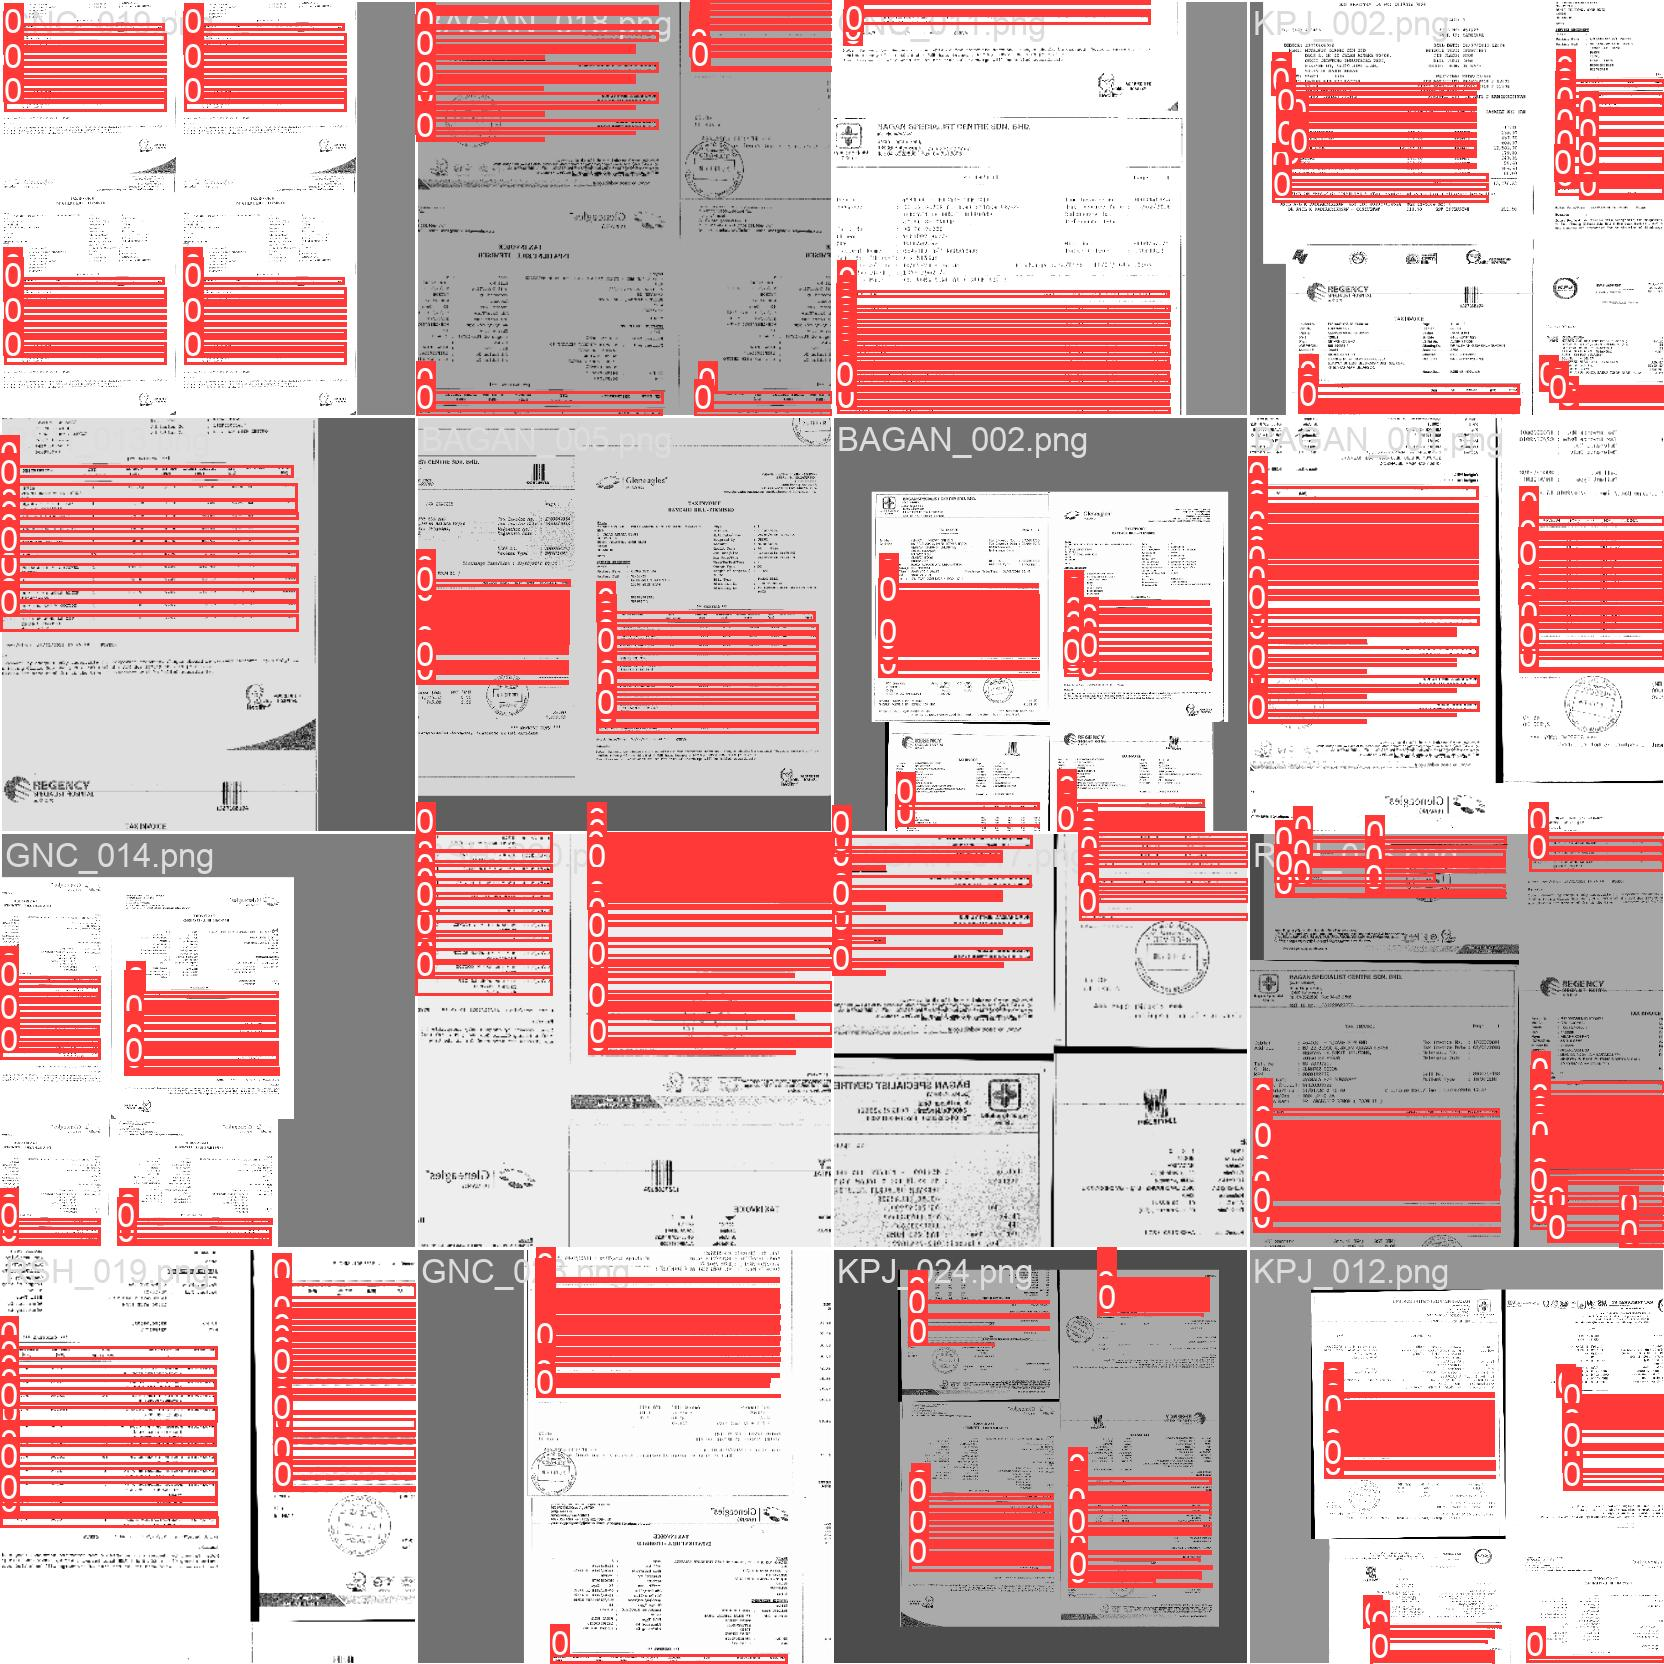

In [10]:
Image(filename=f'{str(results.save_dir)}/train_batch0.jpg', width=900)

## 4.2 Visualize the Labels of Validating Data

In [11]:
Image(filename=f'{str(results.save_dir)}/val_batch0_labels.jpg', width=900)

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train16/val_batch0_labels.jpg'

## 4.3 Visualize the Predicted Testing Data

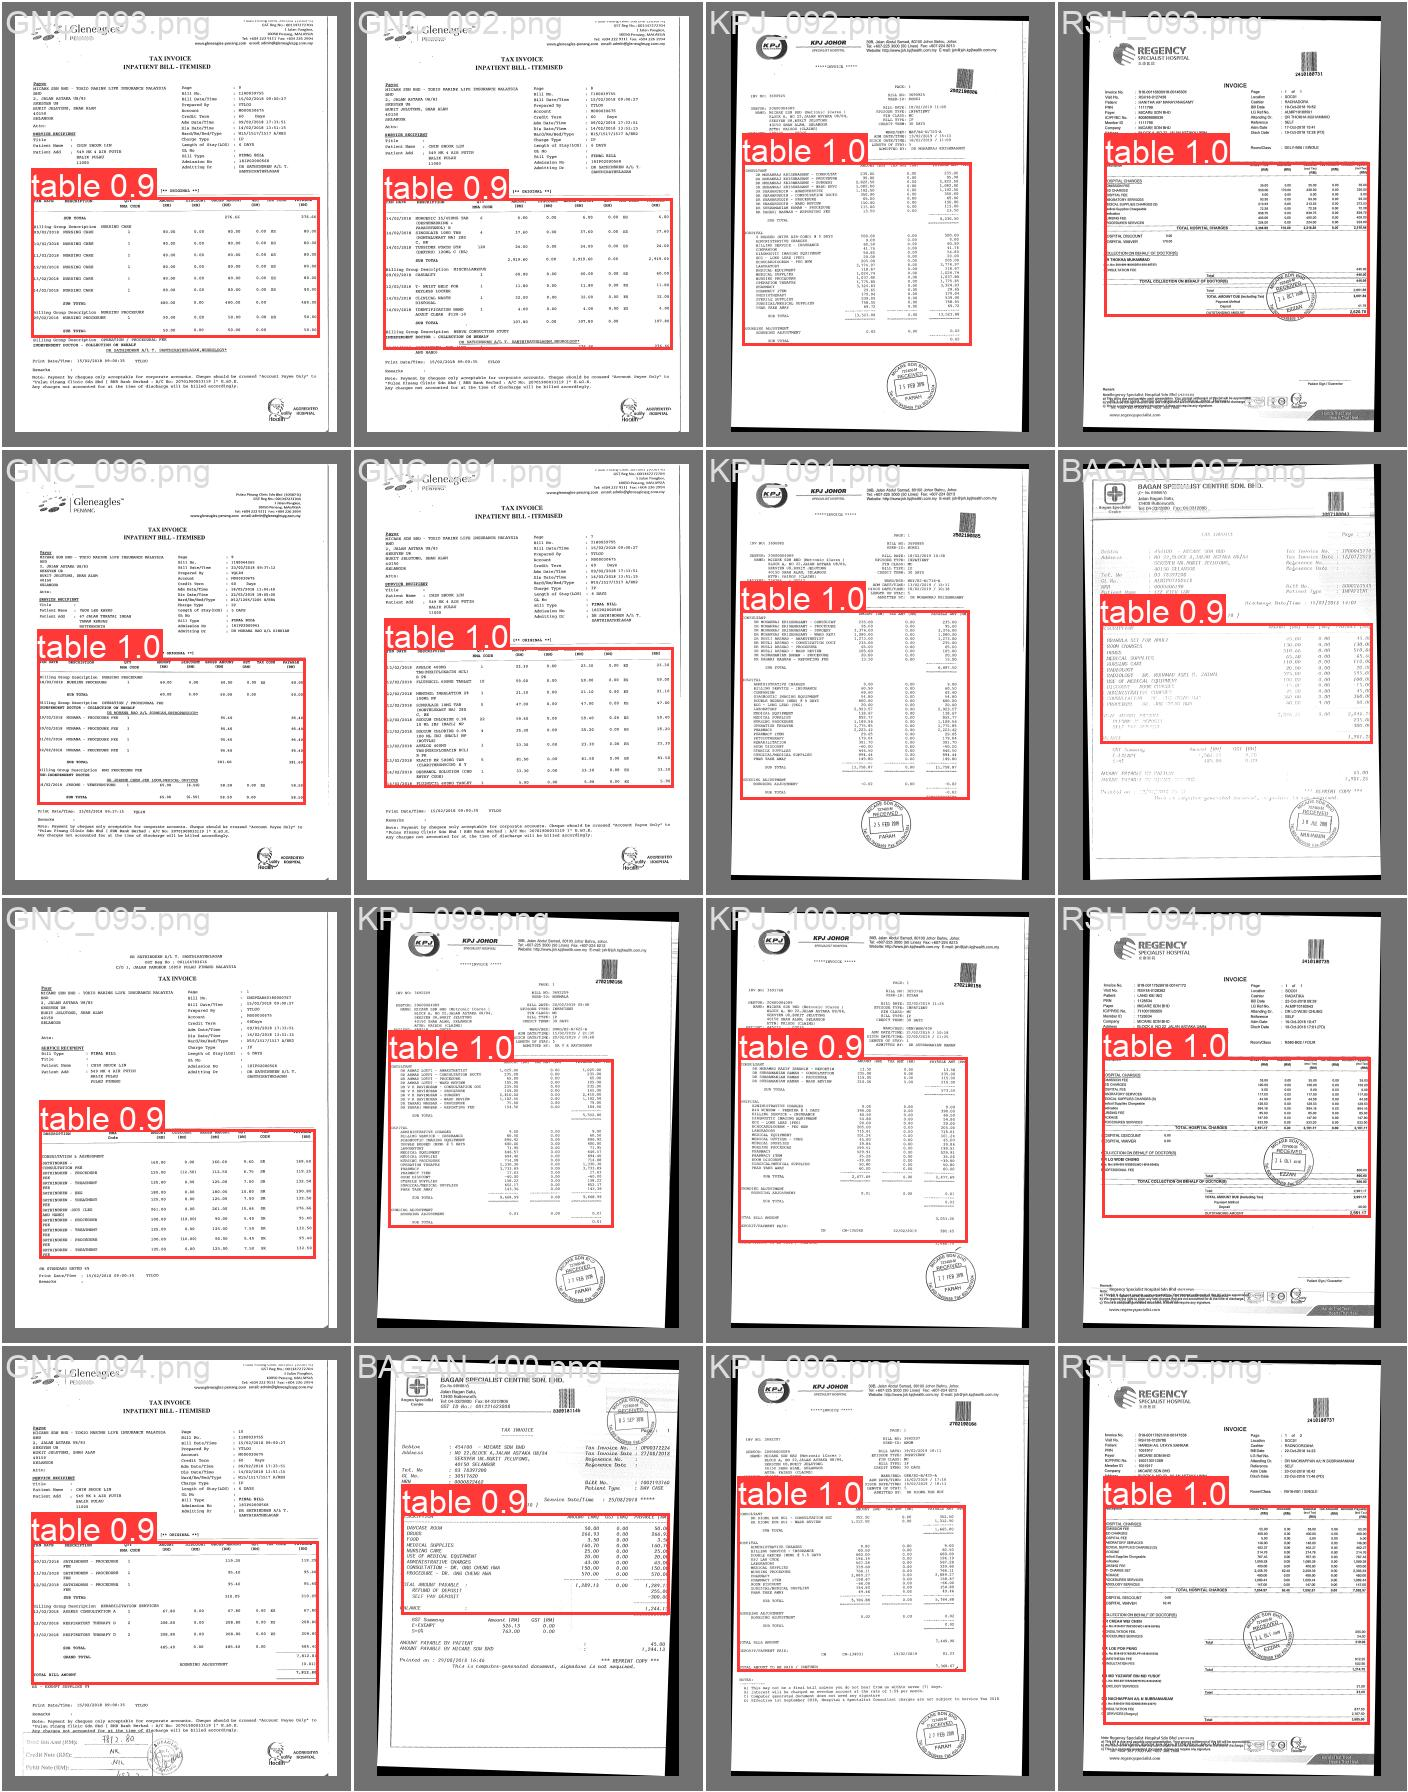

In [9]:
Image(filename=f'{str(results.save_dir)}/val_batch0_pred.jpg', width=900)

# 5 Run Inference  With Trained Weights
Run inference with a pretrained checkpoint on contents of `test/images` folder downloaded from Roboflow.


In [15]:
source = 'Crop_Images'
model = YOLO(f'{str(results.save_dir)}/weights/best.pt')
# model = YOLO('best.pt')

deskewer = DataAugmentation(source)
deskewer.processor()

prediction = model.predict(source=source, save=True, imgsz=416)

1. Crop_Images\TEST_BAGAN_001_crop.jpg
2. Crop_Images\TEST_BAGAN_002_crop.jpg
3. Crop_Images\TEST_BAGAN_003_crop.jpg
4. Crop_Images\TEST_BAGAN_004_crop.jpg
5. Crop_Images\TEST_BAGAN_005_crop.jpg
6. Crop_Images\TEST_BAGAN_006_crop.jpg
7. Crop_Images\TEST_BAGAN_007_crop.jpg
8. Crop_Images\TEST_BAGAN_008_crop.jpg
9. Crop_Images\TEST_BAGAN_009_crop.jpg
10. Crop_Images\TEST_BAGAN_010_crop.jpg
11. Crop_Images\TEST_GNC_001_crop.jpg
12. Crop_Images\TEST_GNC_002_crop.jpg
13. Crop_Images\TEST_GNC_003_crop.jpg
14. Crop_Images\TEST_GNC_004_crop.jpg
15. Crop_Images\TEST_GNC_005_crop.jpg
16. Crop_Images\TEST_GNC_006_crop.jpg
17. Crop_Images\TEST_GNC_007_crop.jpg
18. Crop_Images\TEST_GNC_008_crop.jpg
19. Crop_Images\TEST_GNC_009_crop.jpg
20. Crop_Images\TEST_GNC_010_crop.jpg
21. Crop_Images\TEST_KPJ_001_crop.jpg
22. Crop_Images\TEST_KPJ_002_crop.jpg
23. Crop_Images\TEST_KPJ_003_crop.jpg
24. Crop_Images\TEST_KPJ_004_crop.jpg
25. Crop_Images\TEST_KPJ_005_crop.jpg
26. Crop_Images\TEST_KPJ_006_crop.jpg
2


image 1/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_001_crop.jpg: 288x416 42 rows, 32.1ms
image 2/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_002_crop.jpg: 224x416 40 rows, 33.1ms
image 3/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_003_crop.jpg: 224x416 27 rows, 34.6ms
image 4/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_004_crop.jpg: 224x416 27 rows, 29.5ms
image 5/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_005_crop.jpg: 224x416 24 rows, 35.3ms
image 6/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_006_crop.jpg: 160x416 12 rows, 29.2ms
image 7/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_007_crop.jpg: 256x416 32 rows, 34.2ms
image 8/40 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\TEST_BAGAN_008_crop.jpg: 288x416 39 rows, 36.5ms
image 9/40 C:\Users\CP1\Documents\GitHub\Itemiz